In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from faker import Faker
import random
faker=Faker()
data=[]
cities = ["New York", "Chicago", "Los Angeles", "Houston", "San Francisco"]
ride_status_list = ["Completed", "Cancelled", "No Show"]
for _ in range(500):
    data.append({
       "ride_id": faker.uuid4(),
        "city": random.choice(cities),
        "hour": random.randint(0, 23),  
        "fare": round(random.uniform(5, 50), 2),  
        "ride_status": random.choice(ride_status_list)
    })

    df=pd.DataFrame(data)
    df.to_csv("ride_sharing.csv")

In [3]:
df.head()

,ride_id,city,hour,fare,ride_status
0,8c2f0283-9cab-4c86-bf82-c5e6623060c7,Chicago,10,47.47,No Show
1,0bf58ce2-3d61-41d9-9878-9e55f0ad988e,New York,0,24.45,Cancelled
2,cc1866e3-3050-4cf5-be75-8705a38e5013,Los Angeles,3,48.05,No Show
3,54e82cdf-7b34-467c-a5b9-b80bb1f52829,Houston,11,12.54,Completed
4,697ebb0a-d792-407e-ab71-4621a5e76b6e,Los Angeles,23,22.28,Cancelled


In [ ]:
peak_hours = (
    df.groupby(['city','hour'])
      .size()
      .groupby(level=0)
      .idxmax()
)

print(peak_hours)

('Houston', np.int64(2))


In [7]:
cancel_percent=(df['ride_status']=='Cancelled').mean()*100
print(cancel_percent)

33.4


In [10]:
demand_index=df.groupby('hour').size().values
base=demand_index[0]
de=(demand_index/base)*100
de


array([100.        , 114.28571429, 152.38095238, 133.33333333,
       119.04761905,  90.47619048, 128.57142857,  57.14285714,
        76.19047619,  66.66666667, 100.        ,  95.23809524,
       109.52380952,  71.42857143,  95.23809524,  61.9047619 ,
       114.28571429,  85.71428571, 123.80952381,  66.66666667,
        90.47619048,  85.71428571, 123.80952381, 119.04761905])

In [11]:
smooth = np.convolve(demand_index, np.ones(3)/3, mode='valid')

print(smooth)

[25.66666667 28.         28.33333333 24.         23.66666667 19.33333333
 18.33333333 14.         17.         18.33333333 21.33333333 19.33333333
 19.33333333 16.         19.         18.33333333 22.66666667 19.33333333
 19.66666667 17.         21.         23.        ]


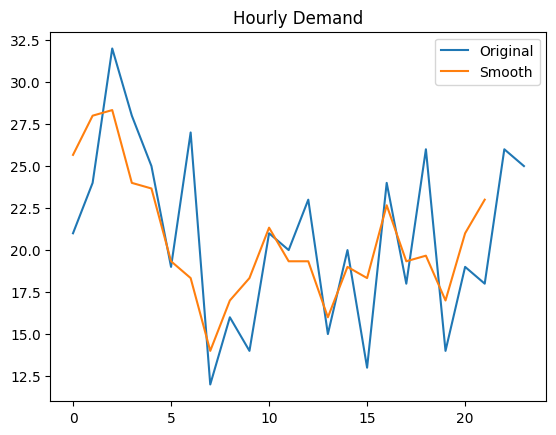

In [12]:
plt.plot(demand_index, label='Original')
plt.plot(smooth, label='Smooth')

plt.legend()
plt.title("Hourly Demand")
plt.show()